In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_4_natural = get_prompt("natural", 4)

prompt_4_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure, and compute the RMSD of the simulation.'

In [3]:
llm_model = "together/meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_4_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To solve this problem, we need to first download the PDB structure of 1LYZ, then simulate it for 1ps at 300 K, and finally compute the RMSD of the simulation and report the secondary structure assignments of the downloaded PDB structure.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```
PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_165222
Thought:

Thought: Now that we have the PDB file, we need to simulate it for 1ps at 300 K. We will use the SetUpandRunFunction tool to set up and run the simulation.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_165222",
    "forcefield_files": ["amber99sbildn.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "ewaldErrorTolerance": 0.0005,
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NPT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "temperature"]
    }
  }
}

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_165222', 'forcefield_files': ['amber99sbildn.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1.0 * nanometers', 'ewaldErrorTolerance': 0.0005, 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle',

Thought: The SetUpandRunFunction tool failed because it couldn't find a template for residue 1 (LYS). This is likely due to the fact that the residue is not in the standard amino acid set. We need to clean the PDB file to replace non-standard residues with standard ones.

Action:
```
{
  "action": "CleaningToolFunction",
  "action_input": {
    "pdb_id": "1LYZ_165222",
    "replace_nonstandard_residues": true,
    "add_missing_atoms": true,
    "remove_heterogens": true,
    "remove_water": true,
    "add_hydrogens": true,
    "add_hydrogens_ph": 7.0
  }
}
```
file path: /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_40/pdb/1LYZ_raw_20251223_165222.pdb


...

Thought: Now that we have simulated the protein for 1ps at 300 K, we need to compute the RMSD of the simulation and report the secondary structure assignments of the downloaded PDB structure. We will use the ComputeRMSD tool to compute the RMSD and the ComputeDSSP tool to report the secondary structure assignments.

Action:
```
{
  "action": "ComputeRMSD",
  "action_input": {
    "top_id": "top_sim0_165243",
    "traj_id": "rec0_165244",
    "ref_top_id": "1LYZ_165240",
    "ref_traj_id": "1LYZ_165240",
    "select": "protein",
    "mol_name": "1LYZ"
  }
}
```

Calculating RMSD...


Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_40/records/rmsd_1LYZ.csv


Plot saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_40/figures/FIG_rmsd_1LYZ_20251223_165436.png

Observation: Succeeded. RMSD calculated and saved to csv with file ID rmsd_1LYZ. Plot saved with plot ID fig0_165436. 
Thought:

Thought: Now that we have computed the RMSD of the simulation, we need to report the secondary structure assignments of the downloaded PDB structure. We will use the ComputeDSSP tool to report the secondary structure assignments.

Action:
```
{
  "action": "ComputeDSSP",
  "action_input": {
    "traj_file": "1LYZ_165222",
    "top_file": "1LYZ_165222",
    "target_frames": "all"
  }
}
```
Observation: {'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}
Thought:

Thought: Now that we have computed the RMSD of the simulation and reported the secondary structure assignments of the downloaded PDB structure, we can provide the final answer.

Action:
```
{
  "action": "Final Answer",
  "action_input": "The simulation of 1LYZ for 1ps at 300 K was successful. The RMSD of the simulation was calculated and saved to csv with file ID rmsd_1LYZ. The plot of the RMSD is saved with plot ID fig0_165436. The secondary structure assignments of the downloaded PDB structure are as follows: 50 residues in helix, 14 residues in strand, 65 residues in coil, and 101 residues not assigned, not a protein residue."
}
```

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    You can only respond with a single complete\n    \'Thought, Action, Action Input\' format\n    OR a single \'Final Answer\' forma

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_165222: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_165222
 1LYZ_165230: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 1LYZ_165240: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_165243: Initial positions for simulation sim0_165243
 sim0_165243: Basic Simulation of Protein 1LYZ_165240
 rec0_165244: Simulation trajectory for protein 1LYZ_165240 and simulation sim0_165243
 rec1_165244: Simulation state log for protein 1LYZ_165240 and simulation sim0_165243
 rec2_165244: Simulation pdb frames for protein 1LYZ_165240 and simulation sim0_165243
 rmsd_1LYZ: RMSD for 1LYZ
 fig0_165436: RMSD plot for 1LYZ
 rec0_165440: dssp values for trajectory with id: 1LYZ_165222


In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_165222"))

In [6]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_165222", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [7]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_165244")
top_path = registry.get_mapped_path("top_sim0_165243")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

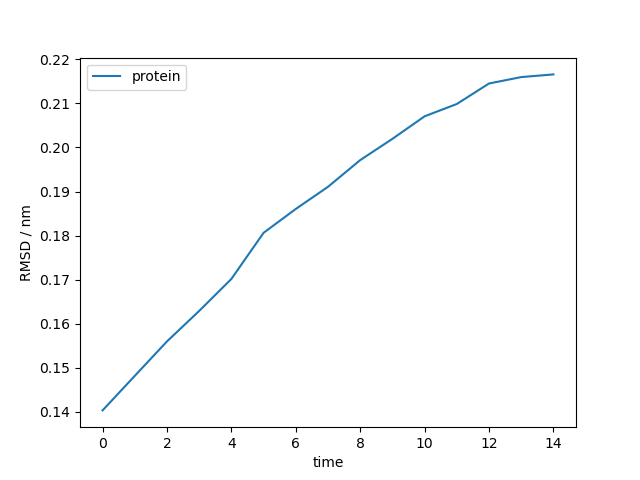

In [8]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_165436'))

In [9]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    if model == 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo':
        model = "llama-v3p1-70b-instruct"
    elif model == 'meta-llama/Meta-Llama-3.1-405B-Instruct-Turbo':
        model = "llama-v3p1-405b-instruct"
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(80771, 1767, 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo')
print('Input tokens:',80771)
print('Output tokens:',1767)
print('LLM costs: $',llm_cost)

Input tokens: 80771
Output tokens: 1767
LLM costs: $ 0.074284
